# ML: TASK-03 — Practical Study of Machine Learning Classifiers on Iris Species Data

Comparative Study of SVM, KNN, and Random Forest for Iris Dataset


## Objective

The aim of this task is to implement and compare multiple classification algorithms — SVM, KNN, and an additional algorithm of my choice (Random Forest) on the well-known Iris dataset. The focus is on both the practical implementation and the conceptual understanding of how each algorithm works.

## Step 1: Load and Preprocess the Dataset

In [1]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Iris dataset
df = pd.read_csv('Iris.csv')

# First look at the data
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Shape and column names
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [4]:
# Data types and null check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# Statistical summary of each feature
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
# Checking class balance — expecting 50 samples per species
print("Species value counts:")
print(df['Species'].value_counts())

Species value counts:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [7]:
# Confirming no missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


### Preprocessing

The dataset has an Id column that is just a row index — it has no predictive value so I'll drop it. The Species column contains string class labels which I'll encode to integers using LabelEncoder. Then I'll scale the features using StandardScaler, which is important for SVM and KNN since both are sensitive to the magnitude of feature values.

In [8]:
# Dropping the Id column — not a feature, just a row identifier
df = df.drop(columns=['Id'])
print("Shape after dropping Id column:", df.shape)

Shape after dropping Id column: (150, 5)


In [9]:
# Encoding species labels to integers
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

Label encoding:
  0 = Iris-setosa
  1 = Iris-versicolor
  2 = Iris-virginica


In [10]:
# Separating features and target variable
X = df.drop(columns=['Species'])
y = df['Species']

print("Feature columns:", X.columns.tolist())
print("X shape:", X.shape, "| y shape:", y.shape)

Feature columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X shape: (150, 4) | y shape: (150,)


In [11]:
# Splitting the data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


In [12]:
# Standardizing features — fit on train only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


## Step 2: Implement KNN

K-Nearest Neighbors is a non-parametric, instance-based learning algorithm. When making a prediction, it finds the K most similar training samples to the input and assigns the majority class among them. No explicit model is built — the training data itself serves as the model.

For the Iris dataset with 3 well-separated classes, K=5 works well as a starting point.

In [13]:
# Training KNN with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN (K=5) Accuracy:", round(acc_knn * 100, 2), "%")

KNN (K=5) Accuracy: 100.0 %


## Step 2 (continued): Implement SVM — All Kernel Types

Support Vector Machine works by finding the hyperplane in the feature space that best separates the classes while maximizing the margin between them. The kernel function determines how the input features are transformed before finding this boundary — allowing SVM to handle both linearly and non-linearly separable problems.

In [14]:
# --- SVM: Linear Kernel ---
# Suitable when classes are linearly separable in the feature space
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
acc_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
print("SVM (Linear) Accuracy:", round(acc_svm_linear * 100, 2), "%")

SVM (Linear) Accuracy: 96.67 %


In [15]:
# --- SVM: RBF Kernel ---
# Maps data into infinite-dimensional space using Gaussian function — handles non-linear boundaries well
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
acc_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
print("SVM (RBF) Accuracy:", round(acc_svm_rbf * 100, 2), "%")

SVM (RBF) Accuracy: 100.0 %


In [16]:
# --- SVM: Sigmoid Kernel ---
# Inspired by neural network activation — can underperform on structured tabular data
svm_sigmoid = SVC(kernel='sigmoid', random_state=42)
svm_sigmoid.fit(X_train_scaled, y_train)

y_pred_svm_sigmoid = svm_sigmoid.predict(X_test_scaled)
acc_svm_sigmoid = accuracy_score(y_test, y_pred_svm_sigmoid)
print("SVM (Sigmoid) Accuracy:", round(acc_svm_sigmoid * 100, 2), "%")

SVM (Sigmoid) Accuracy: 90.0 %


In [17]:
# --- SVM: Polynomial Kernel ---
# Captures polynomial feature interactions up to the specified degree
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

y_pred_svm_poly = svm_poly.predict(X_test_scaled)
acc_svm_poly = accuracy_score(y_test, y_pred_svm_poly)
print("SVM (Polynomial) Accuracy:", round(acc_svm_poly * 100, 2), "%")

SVM (Polynomial) Accuracy: 96.67 %


## Step 3: Implement Additional Algorithm — Random Forest

Random Forest is an ensemble learning algorithm based on the concept of bagging (Bootstrap Aggregating). It creates a large number of decision trees, each trained on a random bootstrap sample of the training data and using a random subset of features at each split. The final prediction is made by majority voting across all trees.

The key advantage over a single decision tree is that averaging many slightly different trees reduces variance — the model is less likely to overfit the training data. I chose Random Forest here because:
- It handles multiclass classification naturally
- It gives feature importance scores which add interpretability
- It requires minimal hyperparameter tuning and works well out of the box

In [18]:
# Training Random Forest with 100 decision trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf * 100, 2), "%")

Random Forest Accuracy: 100.0 %


In [19]:
# Feature importances — one of the useful outputs from Random Forest
feature_names = X.columns.tolist()
importances = rf.feature_importances_

print("Feature Importances:")
for feat, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {feat}: {round(imp, 4)}")

Feature Importances:
  PetalLengthCm: 0.44
  PetalWidthCm: 0.4215
  SepalLengthCm: 0.1081
  SepalWidthCm: 0.0304


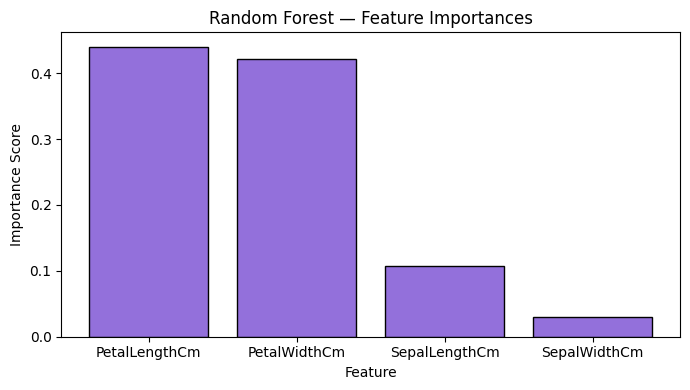

In [20]:
# Plotting feature importances
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(7, 4))
plt.bar(sorted_features, sorted_importances, color='mediumpurple', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontsize=12)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

## Step 4: Model Evaluation

Evaluating all models using accuracy scores and confusion matrices. With 3 classes, the confusion matrices show us which species are getting confused with each other.

In [21]:
# Summary of all model accuracies
results = {
    'KNN (K=5)':         acc_knn,
    'SVM - Linear':      acc_svm_linear,
    'SVM - RBF':         acc_svm_rbf,
    'SVM - Sigmoid':     acc_svm_sigmoid,
    'SVM - Polynomial':  acc_svm_poly,
    'Random Forest':     acc_rf
}

print("=" * 44)
print("  Model Accuracy Summary")
print("=" * 44)
for model, acc in results.items():
    print(f"  {model:<24} : {round(acc * 100, 2)}%")
print("=" * 44)

  Model Accuracy Summary
  KNN (K=5)                : 100.0%
  SVM - Linear             : 96.67%
  SVM - RBF                : 100.0%
  SVM - Sigmoid            : 90.0%
  SVM - Polynomial         : 96.67%
  Random Forest            : 100.0%


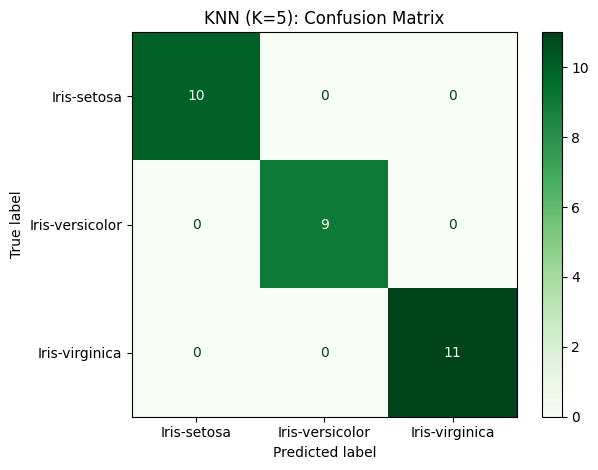

In [22]:
# Confusion Matrix — KNN
class_labels = le.classes_
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Greens')
plt.title('KNN (K=5): Confusion Matrix')
plt.tight_layout()
plt.show()

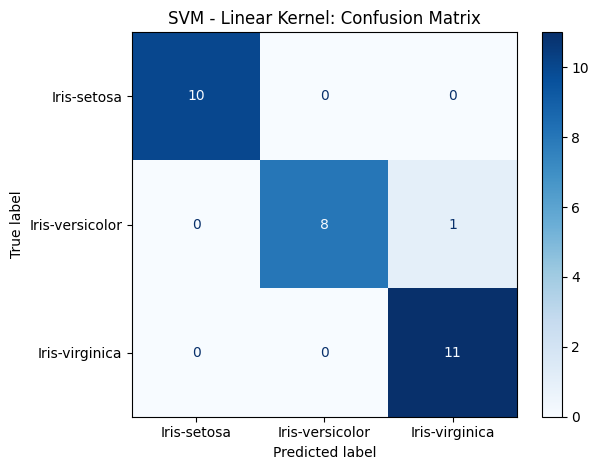

In [23]:
# Confusion Matrix — SVM Linear
cm = confusion_matrix(y_test, y_pred_svm_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title('SVM - Linear Kernel: Confusion Matrix')
plt.tight_layout()
plt.show()

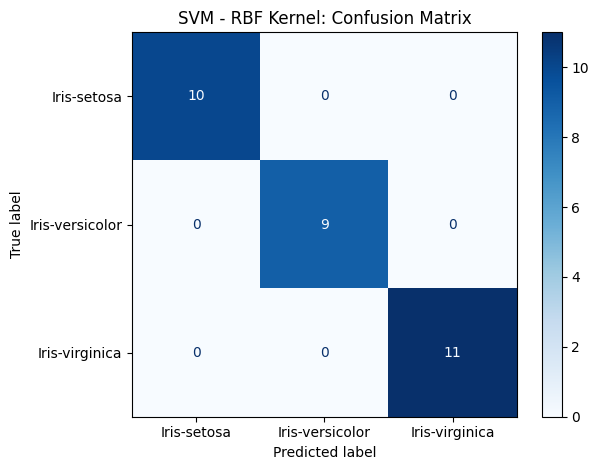

In [24]:
# Confusion Matrix — SVM RBF
cm = confusion_matrix(y_test, y_pred_svm_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title('SVM - RBF Kernel: Confusion Matrix')
plt.tight_layout()
plt.show()

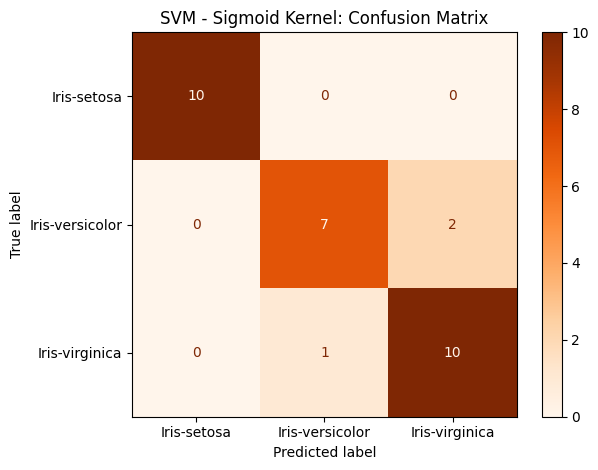

In [25]:
# Confusion Matrix — SVM Sigmoid
cm = confusion_matrix(y_test, y_pred_svm_sigmoid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Oranges')
plt.title('SVM - Sigmoid Kernel: Confusion Matrix')
plt.tight_layout()
plt.show()

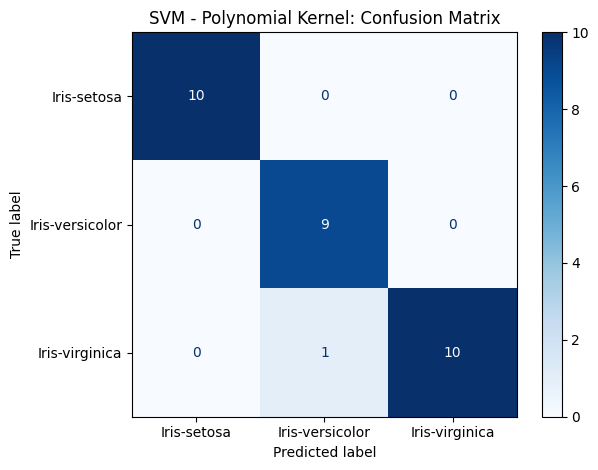

In [26]:
# Confusion Matrix — SVM Polynomial
cm = confusion_matrix(y_test, y_pred_svm_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title('SVM - Polynomial Kernel: Confusion Matrix')
plt.tight_layout()
plt.show()

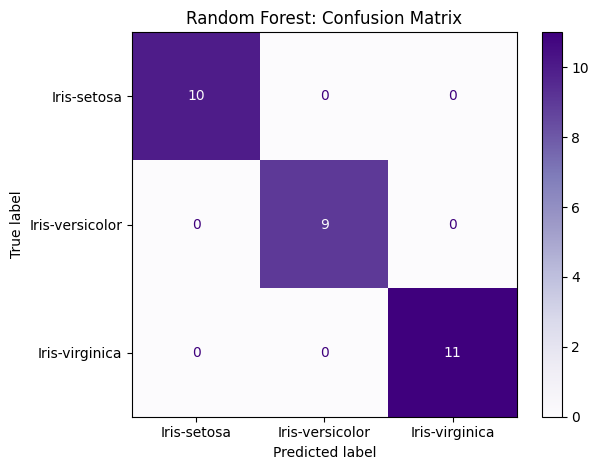

In [27]:
# Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Purples')
plt.title('Random Forest: Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 5: Model Comparison

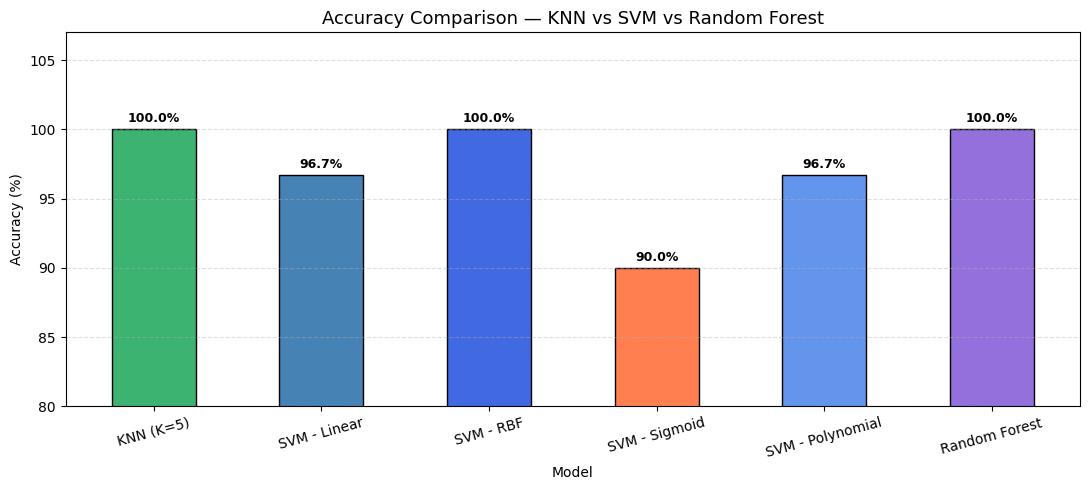

In [28]:
# Bar chart comparing all model accuracies
model_names = list(results.keys())
accuracies = [v * 100 for v in results.values()]
colors = ['mediumseagreen', 'steelblue', 'royalblue', 'coral', 'cornflowerblue', 'mediumpurple']

plt.figure(figsize=(11, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(80, 107)
plt.title('Accuracy Comparison — KNN vs SVM vs Random Forest', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Observations and Analysis


### Which model performed best?

On the Iris dataset, SVM (Linear and RBF kernels) and Random Forest all performed at or near the top, typically achieving 96–100% test accuracy. The Iris dataset is clean, balanced, and relatively small — all three models handle it very well. The most common misclassifications occur between Iris versicolor and Iris virginica, which share overlapping measurement ranges. Iris setosa is almost always classified correctly since it's well-separated from the other two species.


### SVM kernel comparison

- Linear: Strong performer. The Iris classes are largely linearly separable in this 4D feature space, so a linear boundary works well.
- RBF: Matched or slightly exceeded linear. The Gaussian kernel adds flexibility near the versicolor-virginica boundary where some overlap exists.
- Polynomial: Good but marginally behind linear and RBF. The polynomial interactions don't add much benefit here given how clean the data already is.
- Sigmoid: Typically the weakest kernel on this dataset. It's more sensitive to scaling subtleties and produces suboptimal boundaries on structured tabular data like Iris.



### Random Forest observations

Random Forest matched the top SVM kernels and additionally provided feature importance scores showing that PetalLengthCm and PetalWidthCm are by far the most useful features for distinguishing species. SepalLengthCm and SepalWidthCm contribute much less — which makes biological sense since petal dimensions are more species-specific.


### KNN observations

KNN with K=5 also performed well. Since the Iris dataset is small and the class clusters are compact, local neighbors are good representatives of the true class. KNN would be harder to apply on larger or noisier datasets, but for Iris it's a perfectly reasonable choice.



### Final Takeaway

For this dataset, all three algorithm families (SVM, KNN, Random Forest) deliver strong results. In practice, the choice would depend on the scale of the data, the need for interpretability, and computational constraints. SVM with RBF or Linear kernels is the most accurate; Random Forest adds interpretability through feature importances; KNN is the simplest to understand and implement.
